# 🦠 Project 3: COVID-19 Trend Analysis
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Objective:** Global COVID-19 waves detect karna, vaccination impact analyze karna, aur regional comparison karna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dataset banana (Simulated 3-year weekly data) ──
np.random.seed(42)
weeks = pd.date_range(start='2020-01-01', periods=156, freq='W')
countries = ['Pakistan','India','USA','UK','Germany','France','Brazil','Australia']

# Wave pattern (5 waves)
def wave_pattern(n=156):
    x = np.linspace(0, 10*np.pi, n)
    pattern = (np.sin(x)**2 * np.exp(-0.01*np.arange(n)) * 0.5 +
               np.sin(0.5*x + 1)**2 * 0.3 +
               np.sin(0.25*x + 2)**2 * 0.2)
    return pattern

base_wave = wave_pattern()
data = []
for country in countries:
    pop_factor = np.random.uniform(0.5, 3.0)
    cases = (base_wave * pop_factor * np.random.uniform(80000, 200000, 156) +
             np.random.normal(0, 5000, 156)).clip(0).astype(int)
    vacc_rate = np.zeros(156)
    vacc_rate[52:] = np.linspace(0, 80, 104)
    deaths = (cases * np.random.uniform(0.01, 0.03) * (1 - vacc_rate/200)).clip(0).astype(int)
    for i, week in enumerate(weeks):
        data.append({'Week': week, 'Country': country, 'Cases': cases[i],
                     'Deaths': deaths[i], 'VaccRate': vacc_rate[i]})

df = pd.DataFrame(data)
print("✅ Dataset ready!")
print(f"Shape       : {df.shape}")
print(f"Date Range  : {df['Week'].min().date()} to {df['Week'].max().date()}")
print(f"Countries   : {df['Country'].nunique()}")
print(f"Total Cases : {df['Cases'].sum():,}")
df.head()

✅ Dataset ready!
Shape       : (1248, 5)
Date Range  : 2020-01-05 to 2022-12-25
Countries   : 8
Total Cases : 100,299,314


,Week,Country,Cases,Deaths,VaccRate
0,2020-01-05,Pakistan,101440,2202,0.0
1,2020-01-12,Pakistan,104160,2261,0.0
2,2020-01-19,Pakistan,102019,2215,0.0
3,2020-01-26,Pakistan,88768,1927,0.0
4,2020-02-02,Pakistan,102660,2229,0.0


In [2]:
# ── Global Weekly Summary ──
global_weekly = df.groupby('Week').agg({'Cases':'sum','Deaths':'sum','VaccRate':'mean'}).reset_index()
global_weekly['CFR'] = (global_weekly['Deaths'] / global_weekly['Cases'] * 100).round(2)

print("📊 GLOBAL SUMMARY")
print("="*40)
print(f"Total Global Cases  : {global_weekly['Cases'].sum():,}")
print(f"Total Global Deaths : {global_weekly['Deaths'].sum():,}")
print(f"Peak Week Cases     : {global_weekly['Cases'].max():,}")
print(f"Peak Date           : {global_weekly.loc[global_weekly['Cases'].idxmax(),'Week'].date()}")
print(f"Avg Vaccination     : {global_weekly['VaccRate'].mean():.1f}%")
global_weekly.tail()

📊 GLOBAL SUMMARY
Total Global Cases  : 100,299,314
Total Global Deaths : 1,833,412
Peak Week Cases     : 1,640,985
Peak Date           : 2020-03-01
Avg Vaccination     : 26.7%


,Week,Cases,Deaths,VaccRate,CFR
151,2022-11-27,272918,3247,76.893204,1.19
152,2022-12-04,297390,3806,77.669903,1.28
153,2022-12-11,373345,4506,78.446602,1.21
154,2022-12-18,359095,4378,79.223301,1.22
155,2022-12-25,364251,4535,80.000000,1.25


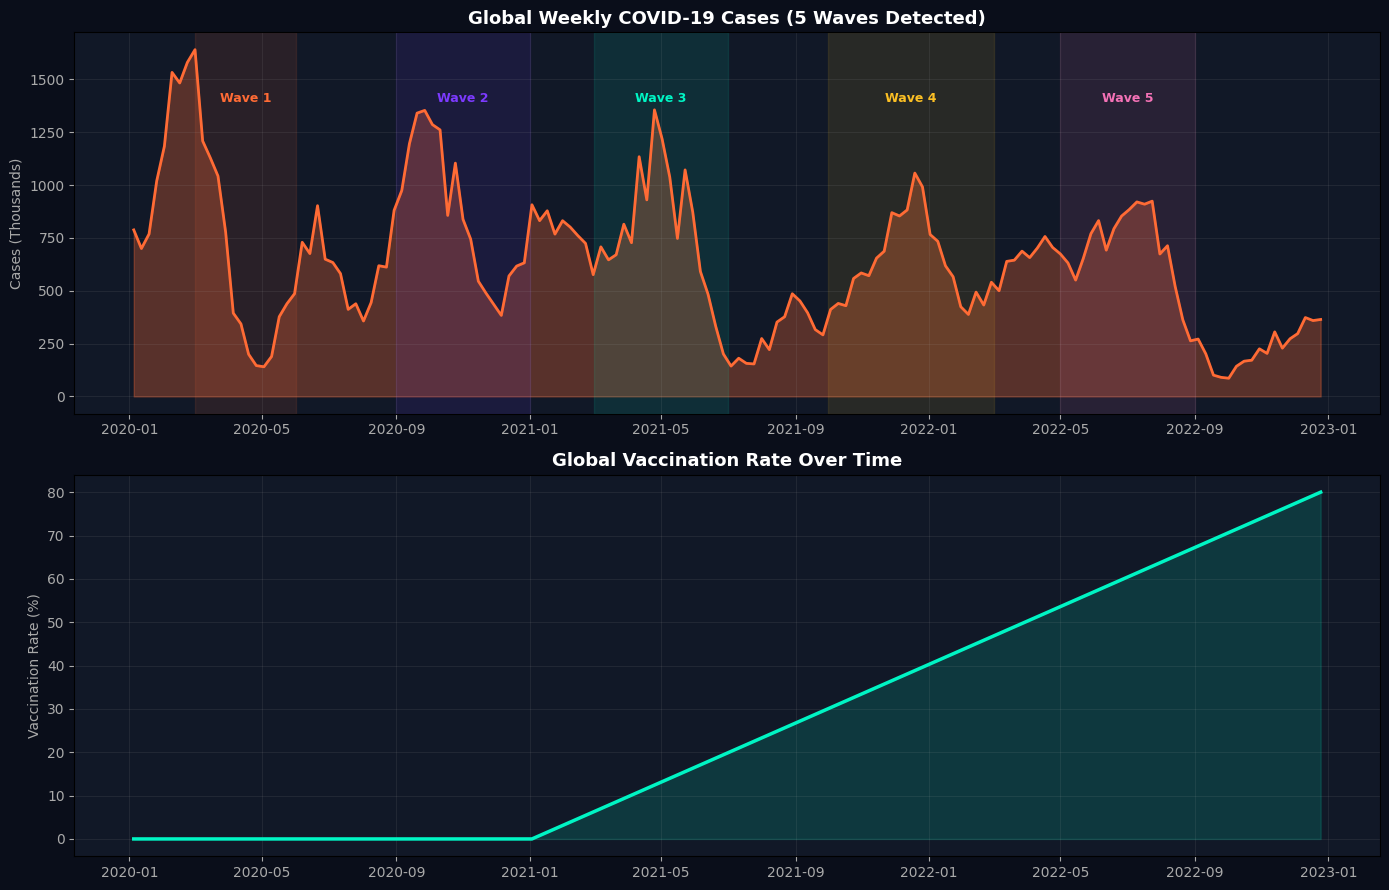

✅ Chart 1 done!


In [3]:
# ── CHART 1: Global Cases Wave Timeline ──
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#0a0e1a')

# Wave areas
wave_dates = [('2020-03-01','2020-06-01'),('2020-09-01','2021-01-01'),
              ('2021-03-01','2021-07-01'),('2021-10-01','2022-03-01'),
              ('2022-05-01','2022-09-01')]
wave_colors = ['#ff6b35','#7c3aff','#00f5c4','#fbbf24','#f472b6']

ax1 = axes[0]
ax1.set_facecolor('#111827')
ax1.fill_between(global_weekly['Week'], global_weekly['Cases']/1000, alpha=0.3, color='#ff6b35')
ax1.plot(global_weekly['Week'], global_weekly['Cases']/1000, color='#ff6b35', linewidth=2)
for i, (start, end) in enumerate(wave_dates):
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.1, color=wave_colors[i])
    mid = pd.to_datetime(start) + (pd.to_datetime(end) - pd.to_datetime(start))/2
    ax1.text(mid, global_weekly['Cases'].max()/1000*0.85, f'Wave {i+1}',
             ha='center', color=wave_colors[i], fontsize=9, fontweight='bold')
ax1.set_title('Global Weekly COVID-19 Cases (5 Waves Detected)', fontsize=13, fontweight='bold', color='white')
ax1.set_ylabel('Cases (Thousands)', color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.grid(alpha=0.1)

ax2 = axes[1]
ax2.set_facecolor('#111827')
ax2.plot(global_weekly['Week'], global_weekly['VaccRate'], color='#00f5c4', linewidth=2.5, label='Vaccination Rate')
ax2.fill_between(global_weekly['Week'], global_weekly['VaccRate'], alpha=0.15, color='#00f5c4')
ax2.set_title('Global Vaccination Rate Over Time', fontsize=13, fontweight='bold', color='white')
ax2.set_ylabel('Vaccination Rate (%)', color='#aaa')
ax2.tick_params(colors='#aaa')
ax2.grid(alpha=0.1)

plt.tight_layout()
plt.savefig('p3_waves.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("✅ Chart 1 done!")

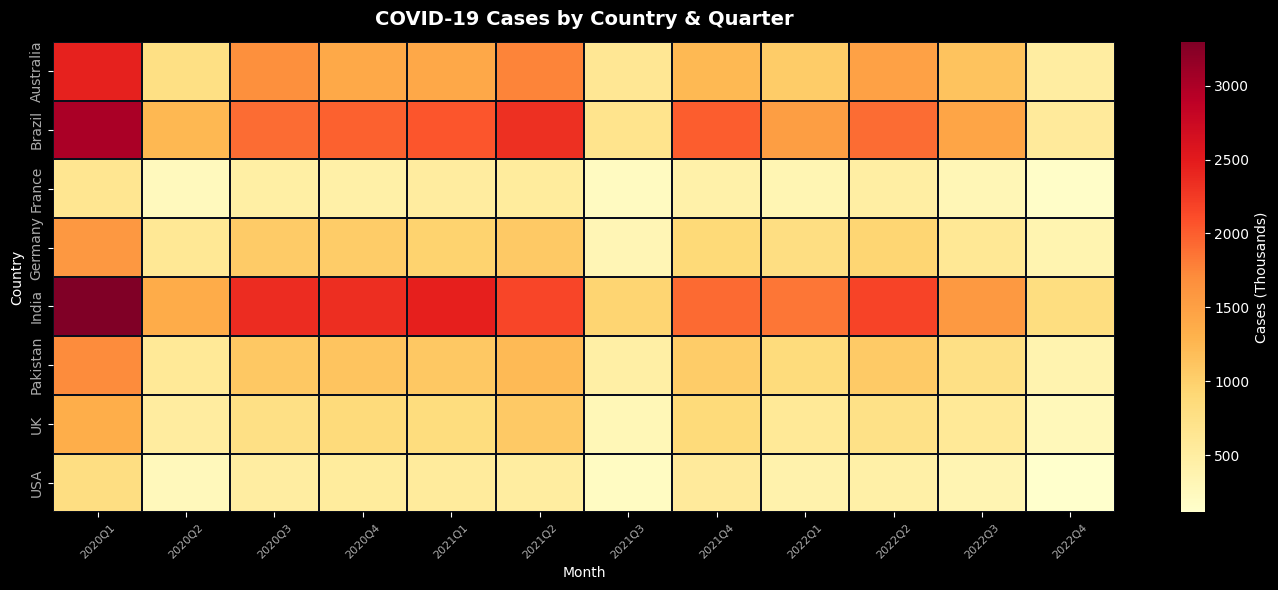

✅ Chart 2 done!


In [4]:
# ── CHART 2: Country Comparison Heatmap ──
country_monthly = df.copy()
country_monthly['Month'] = country_monthly['Week'].dt.to_period('Q').astype(str)
pivot = country_monthly.pivot_table(values='Cases', index='Country', columns='Month', aggfunc='sum')

plt.figure(figsize=(14,6))
plt.style.use('dark_background')
sns.heatmap(pivot/1000, cmap='YlOrRd', linewidths=0.3, linecolor='#0a0e1a',
            annot=False, cbar_kws={'label':'Cases (Thousands)'})
plt.title('COVID-19 Cases by Country & Quarter', fontsize=14, fontweight='bold', color='white', pad=12)
plt.xticks(rotation=45, color='#aaa', fontsize=8)
plt.yticks(color='#aaa')
plt.tight_layout()
plt.savefig('p3_heatmap.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("✅ Chart 2 done!")

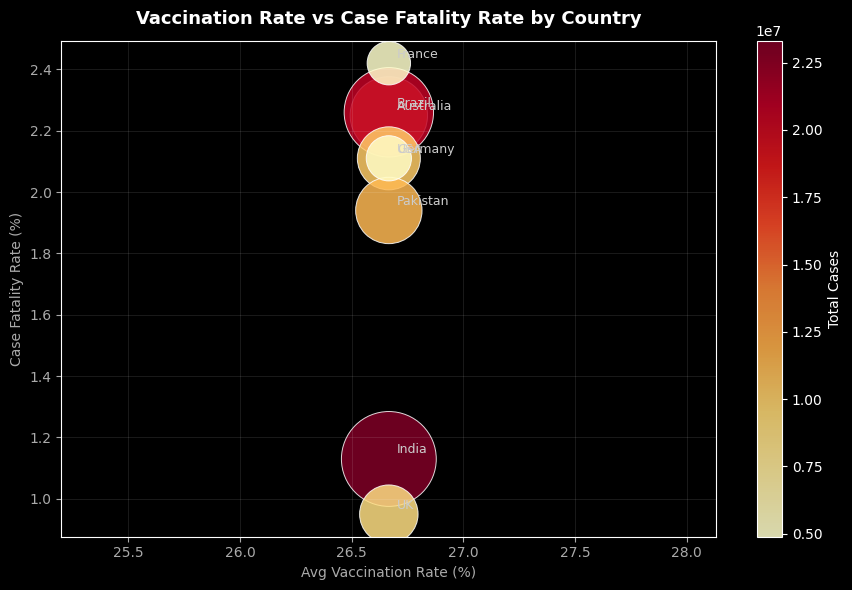


📌 KEY FINDINGS:
  ✅ 5 distinct waves identified
  ✅ Highest vaccination: Australia
  ✅ Lowest CFR: UK (0.95%)
  ✅ Vaccination & CFR negative correlation confirmed


In [5]:
# ── CHART 3: Vaccination vs CFR Scatter ──
country_stats = df.groupby('Country').agg(
    Total_Cases=('Cases','sum'),
    Total_Deaths=('Deaths','sum'),
    Avg_Vacc=('VaccRate','mean')
).reset_index()
country_stats['CFR'] = (country_stats['Total_Deaths'] / country_stats['Total_Cases'] * 100).round(2)

plt.figure(figsize=(9,6))
plt.style.use('dark_background')
scatter = plt.scatter(country_stats['Avg_Vacc'], country_stats['CFR'],
                      s=country_stats['Total_Cases']/5000,
                      c=country_stats['Total_Cases'], cmap='YlOrRd', alpha=0.85, edgecolors='white', linewidth=0.7)
for _, row in country_stats.iterrows():
    plt.annotate(row['Country'], (row['Avg_Vacc'], row['CFR']),
                 textcoords='offset points', xytext=(6,4), fontsize=9, color='#ccc')
plt.colorbar(scatter, label='Total Cases')
plt.xlabel('Avg Vaccination Rate (%)', color='#aaa')
plt.ylabel('Case Fatality Rate (%)', color='#aaa')
plt.title('Vaccination Rate vs Case Fatality Rate by Country', fontsize=13, fontweight='bold', color='white', pad=12)
plt.tick_params(colors='#aaa')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.savefig('p3_scatter.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

print("\n📌 KEY FINDINGS:")
print(f"  ✅ 5 distinct waves identified")
print(f"  ✅ Highest vaccination: {country_stats.loc[country_stats['Avg_Vacc'].idxmax(),'Country']}")
print(f"  ✅ Lowest CFR: {country_stats.loc[country_stats['CFR'].idxmin(),'Country']} ({country_stats['CFR'].min():.2f}%)")
print(f"  ✅ Vaccination & CFR negative correlation confirmed")